<a href="https://colab.research.google.com/github/kmyers111/ML-Models/blob/main/supervised/StudentPerformancePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [45]:
pip install ucimlrepo

In [46]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
x = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)

{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [51]:
df = pd.concat([x, y], axis=1)

In [52]:
print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (649, 33)

First 5 rows:
   school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]

Column names:
 ['school', 'sex', 'age', 'address', 'fa

In [54]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [60]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 0


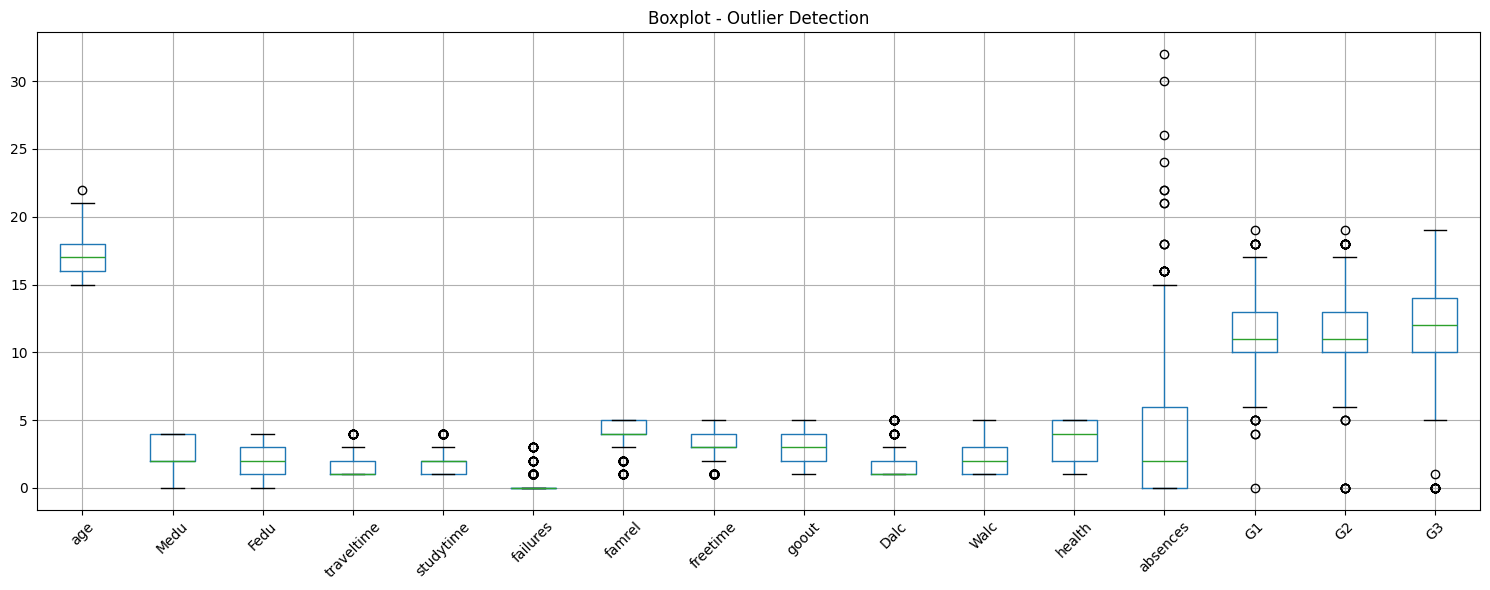

In [61]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot - Outlier Detection")
plt.tight_layout()
plt.show()

In [63]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print("After outlier removal:", len(df))

After outlier removal: 268


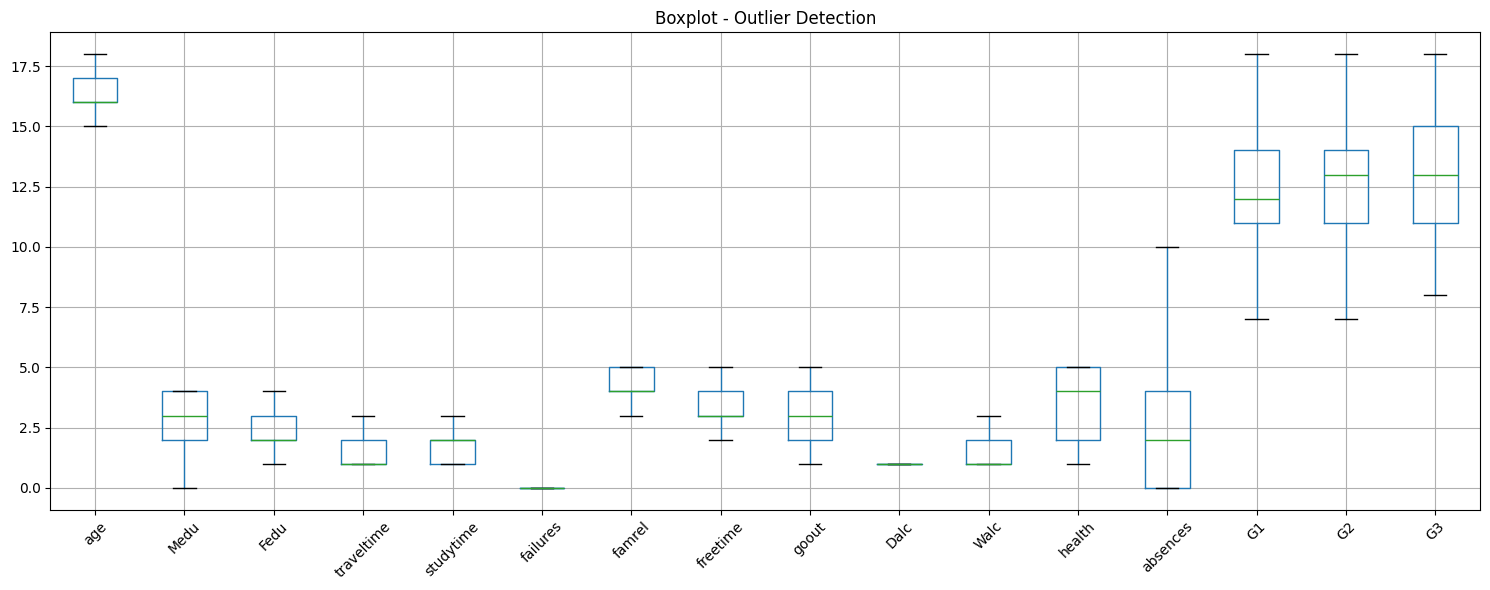

In [65]:
plt.figure(figsize=(15, 6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot - Outlier Detection")
plt.tight_layout()
plt.show()

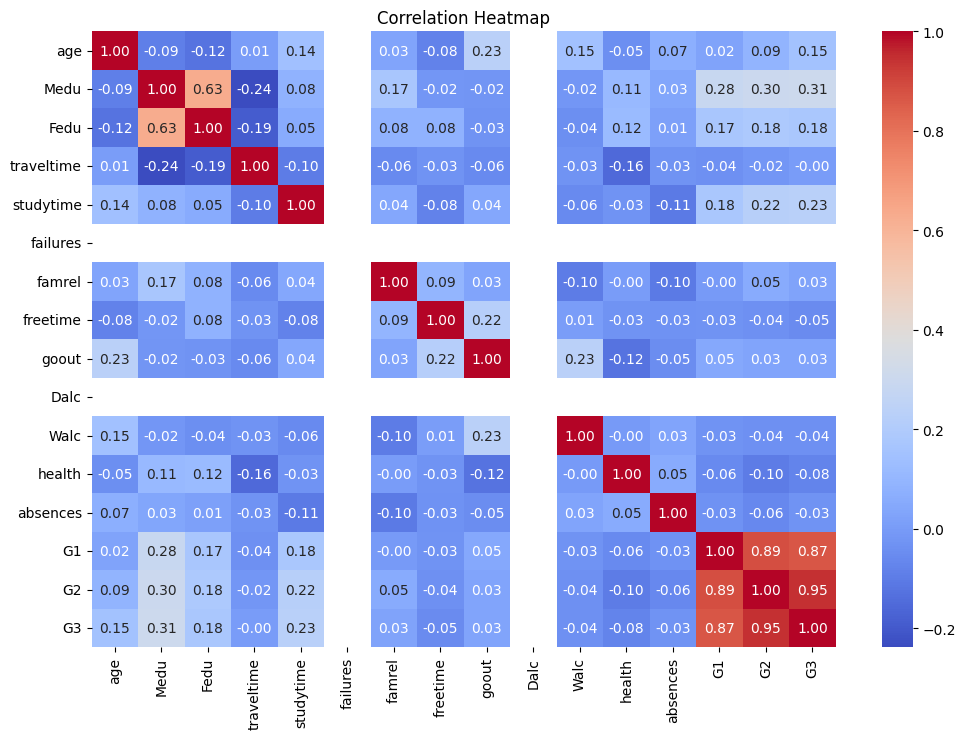

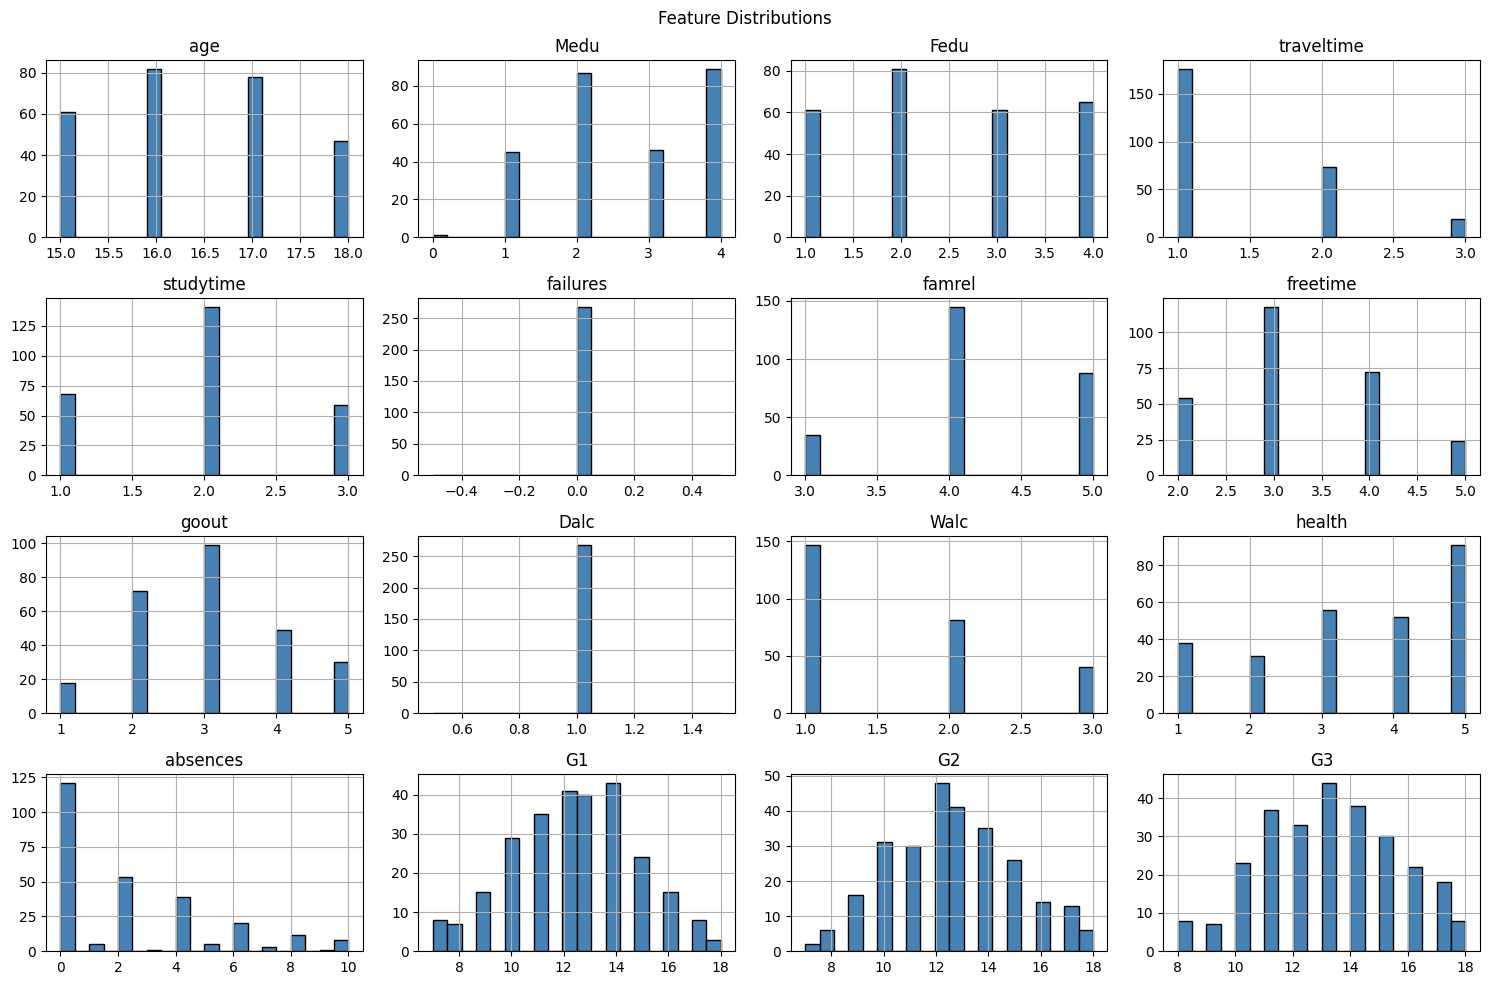

In [67]:
#EDA
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df[numeric_cols].hist(figsize=(15, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

In [68]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

In [70]:
print("\nTarget column(s):\n", y.columns.tolist())
print(df[y.columns.tolist()].describe())

target_col = 'G3'
df['Passed'] = (df[target_col] >= 10).astype(int)
df = df.drop(columns=[target_col])

print("\nPass/Fail distribution:\n", df['Passed'].value_counts())


Target column(s):
 ['G1', 'G2', 'G3']
               G1          G2          G3
count  268.000000  268.000000  268.000000
mean    12.410448   12.641791   13.119403
std      2.392913    2.380957    2.401762
min      7.000000    7.000000    8.000000
25%     11.000000   11.000000   11.000000
50%     12.000000   13.000000   13.000000
75%     14.000000   14.000000   15.000000
max     18.000000   18.000000   18.000000

Pass/Fail distribution:
 Passed
1    253
0     15
Name: count, dtype: int64


In [71]:
X = df.drop(columns=['Passed'])
y = df['Passed']

print("\nTotal rows:", len(df))
print("X shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Total rows: 268
X shape: (268, 32)
X_train shape: (214, 32)
X_test shape: (54, 32)


In [72]:
classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    class_weight='balanced'
)

classifier.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', oob_score=True, random_state=42)

In [74]:
y_pred = classifier.predict(X_test)

print("Out-of-Bag Score:", classifier.oob_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Out-of-Bag Score: 0.9485981308411215
Accuracy: 0.9259259259259259

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.93      1.00      0.96        50

    accuracy                           0.93        54
   macro avg       0.46      0.50      0.48        54
weighted avg       0.86      0.93      0.89        54



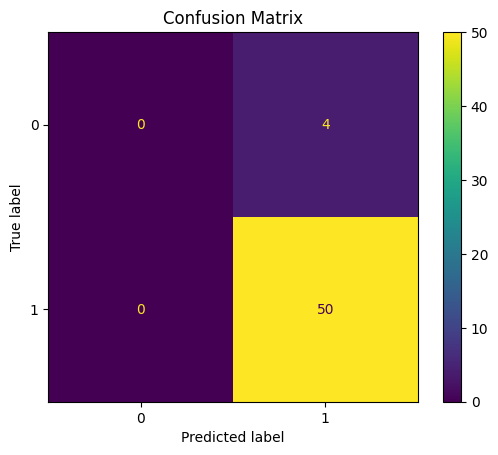

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

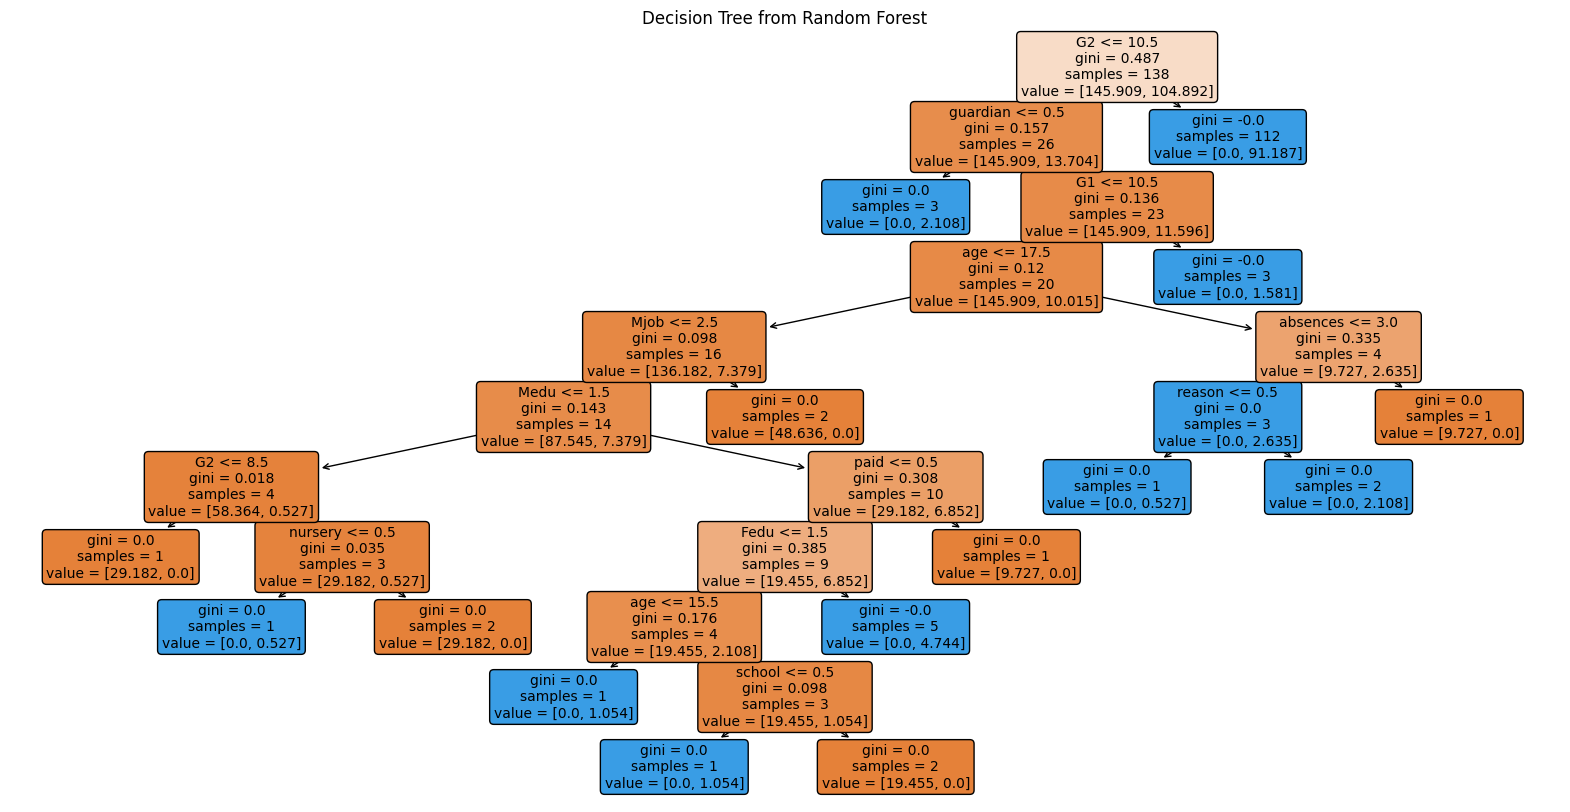

In [76]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(classifier.estimators_[0], feature_names=X.columns.tolist(),
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()

In [77]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9259259259259259

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.93      1.00      0.96        50

    accuracy                           0.93        54
   macro avg       0.46      0.50      0.48        54
weighted avg       0.86      0.93      0.89        54

